Количество итераций: 10,000
Бюджет валовой прибыли: 3,000,000,000 руб.
--------------------------------------------------------------------------------

 СТРУКТУРА ВЫРУЧКИ:
Направление                               Прогноз      min     mode      max
---------------------------------------------------------------------------
Продуктовое направление          3,000,000,000.00      95%     105%     110%
Федеральное направление         10,000,000,000.00      95%     105%     110%
Партнерские продажи              1,150,000,000.00      95%     105%     110%
ИТОГО                           14,150,000,000.00
---------------------------------------------------------------------------

 СТРУКТУРА СЕБЕСТОИМОСТИ:
Статья                                    Прогноз      min     mode      max
---------------------------------------------------------------------------
Штрафы                                 25,000,000      95%     105%     110%
Расходы на персонал                 9,000,000,000      95%  

/tmp/ipykernel_16554/3990243749.py:386: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(coef_data_cogs, labels=labels_cogs, vert=False, patch_artist=True, showmeans=True)
/tmp/ipykernel_16554/3990243749.py:400: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = ax4.boxplot(coef_data_opex, labels=labels_opex, vert=False, patch_artist=True, showmeans=True)


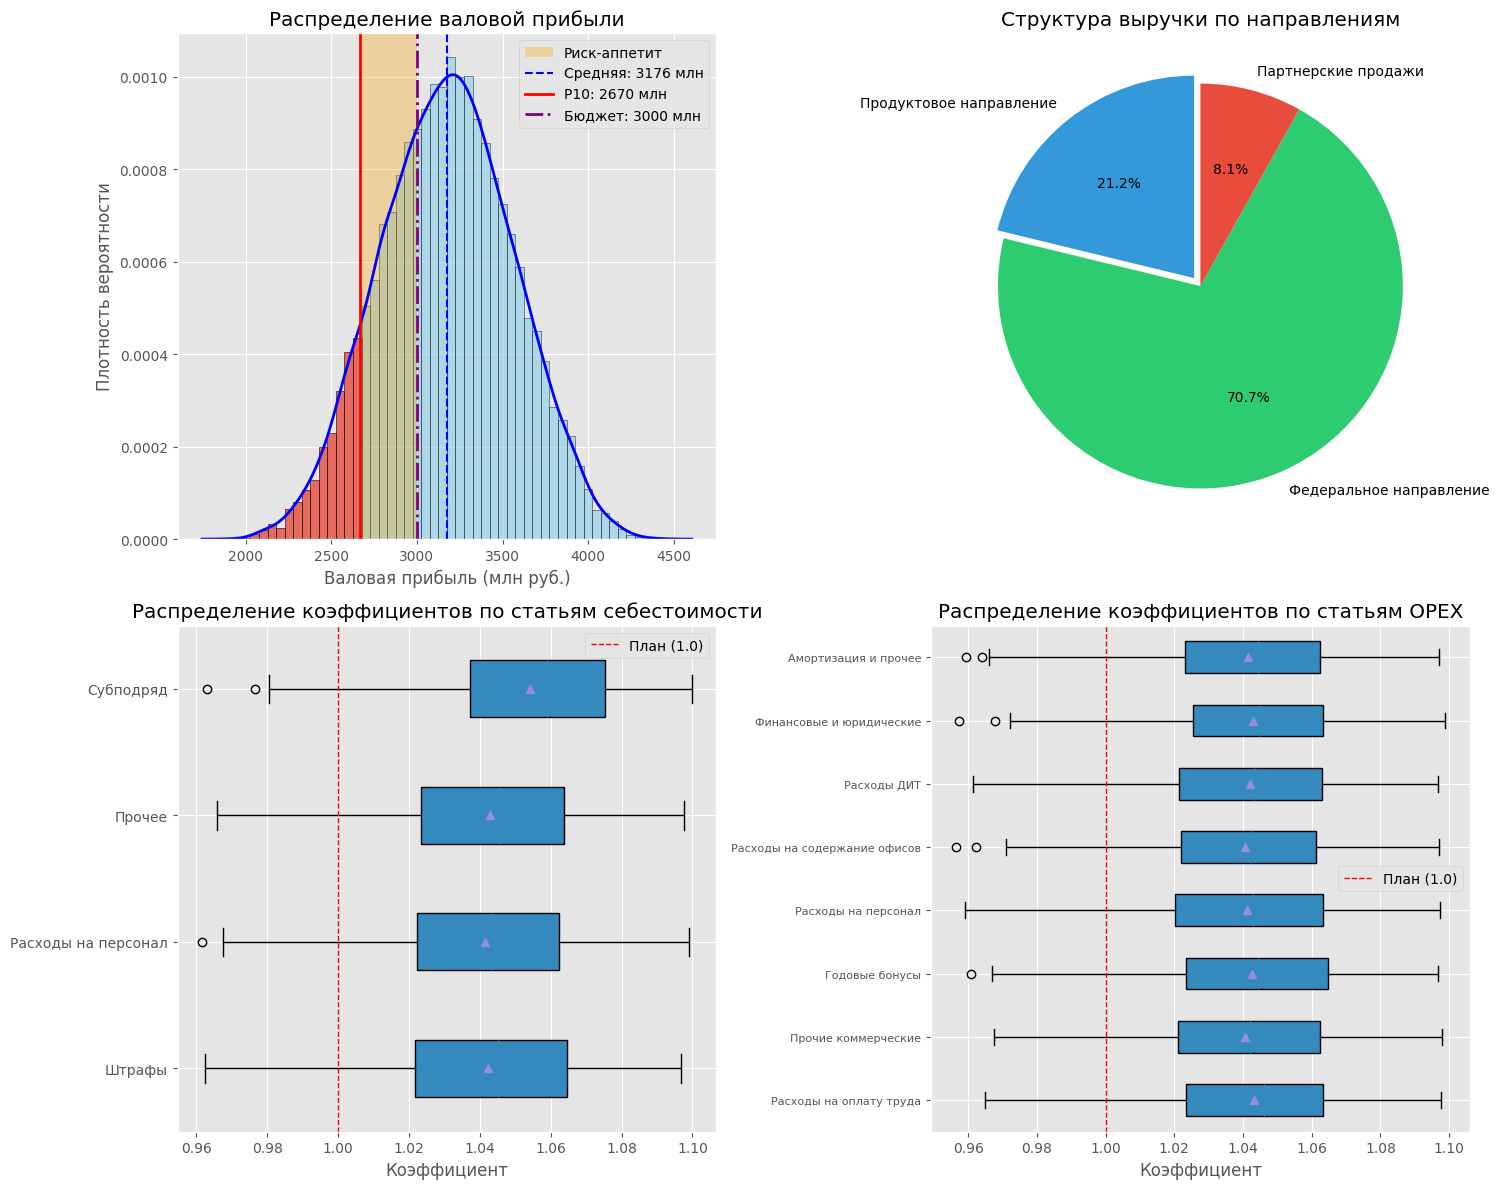

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


REVENUE_ITEMS = {
    'Продуктовое направление': {
        'forecast': 3_000_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Федеральное направление': {
        'forecast': 10_000_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Партнерские продажи': {
        'forecast': 1_150_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    }
}


COGS_ITEMS = {
    'Штрафы': {
        'forecast': 25_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Расходы на персонал': {
        'forecast': 9_000_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Прочее': {
        'forecast': 50_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Субподряд': {
        'forecast': 2_000_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.07,
        'max_coef': 1.10
    }
}


OPEX_ITEMS = {
    'Расходы на оплату труда': {
        'forecast': 1_000_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Прочие коммерческие': {
        'forecast': 70_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Годовые бонусы': {
        'forecast': 450_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Расходы на персонал': {
        'forecast': 150_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Расходы на содержание офисов': {
        'forecast': 50_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Расходы ДИТ': {
        'forecast': 100_148_272.03,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Финансовые и юридические': {
        'forecast': 200_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    },
    'Амортизация и прочее': {
        'forecast': 250_000_000,
        'min_coef': 0.95,
        'mode_coef': 1.05,
        'max_coef': 1.10
    }
}


AMORTIZATION_FORECAST = 900_000_000
AMORT_PARAMS = {
    'min_coef': 0.95,
    'mode_coef': 1.05,
    'max_coef': 1.10
}

TOTAL_REVENUE_FORECAST = sum(item['forecast'] for item in REVENUE_ITEMS.values())
TOTAL_COGS_FORECAST = sum(item['forecast'] for item in COGS_ITEMS.values())
TOTAL_OPEX_FORECAST = sum(item['forecast'] for item in OPEX_ITEMS.values())
GROSS_PROFIT_FORECAST = TOTAL_REVENUE_FORECAST - TOTAL_COGS_FORECAST
OIBDA_FORECAST = GROSS_PROFIT_FORECAST - TOTAL_OPEX_FORECAST + AMORTIZATION_FORECAST

BUDGET_GROSS_PROFIT = 3_000_000_000


N_SIMULATIONS = 10000


def pert_sample(min_val, mode_val, max_val, size=1, lam=4):

    mean_val = (min_val + lam * mode_val + max_val) / (lam + 2)

    alpha = (mean_val - min_val) * (2 * mode_val - min_val - max_val) / ((mode_val - mean_val) * (max_val - min_val))
    beta = alpha * (max_val - mean_val) / (mean_val - min_val)

    if alpha <= 0 or beta <= 0 or not np.isfinite(alpha) or not np.isfinite(beta):

        u = np.random.random(size)
        fc = (mode_val - min_val) / (max_val - min_val)
        result = np.zeros(size)
        mask = u <= fc
        result[mask] = min_val + np.sqrt(u[mask] * (max_val - min_val) * (mode_val - min_val))
        result[~mask] = max_val - np.sqrt((1 - u[~mask]) * (max_val - min_val) * (max_val - mode_val))
        return result

    samples = stats.beta.rvs(alpha, beta, size=size)
    return min_val + samples * (max_val - min_val)


def get_random_coef(params, size=1):

    return pert_sample(params['min_coef'], params['mode_coef'], params['max_coef'], size)


def run_simulation():



    revenue_detail = {name: np.zeros(N_SIMULATIONS) for name in REVENUE_ITEMS}
    cogs_detail = {name: np.zeros(N_SIMULATIONS) for name in COGS_ITEMS}
    opex_detail = {name: np.zeros(N_SIMULATIONS) for name in OPEX_ITEMS}

    revenue_samples = np.zeros(N_SIMULATIONS)
    cogs_samples = np.zeros(N_SIMULATIONS)
    opex_samples = np.zeros(N_SIMULATIONS)
    amort_samples = np.zeros(N_SIMULATIONS)
    gross_profit_samples = np.zeros(N_SIMULATIONS)
    oibda_samples = np.zeros(N_SIMULATIONS)

    for i in range(N_SIMULATIONS):

        total_revenue = 0
        for name, item in REVENUE_ITEMS.items():
            coef = get_random_coef(item, 1)[0]
            revenue_value = item['forecast'] * coef
            revenue_detail[name][i] = revenue_value
            total_revenue += revenue_value
        revenue_samples[i] = total_revenue


        total_cogs = 0
        for name, item in COGS_ITEMS.items():
            coef = get_random_coef(item, 1)[0]
            cost_value = item['forecast'] * coef
            cogs_detail[name][i] = cost_value
            total_cogs += cost_value
        cogs_samples[i] = total_cogs


        total_opex = 0
        for name, item in OPEX_ITEMS.items():
            coef = get_random_coef(item, 1)[0]
            cost_value = item['forecast'] * coef
            opex_detail[name][i] = cost_value
            total_opex += cost_value
        opex_samples[i] = total_opex


        amort_coef = get_random_coef(AMORT_PARAMS, 1)[0]
        amort_samples[i] = AMORTIZATION_FORECAST * amort_coef


        gross_profit_samples[i] = revenue_samples[i] - cogs_samples[i]


        oibda_samples[i] = gross_profit_samples[i] - opex_samples[i] + amort_samples[i]

    return {
        'revenue_detail': revenue_detail,
        'revenue': revenue_samples,
        'cogs_detail': cogs_detail,
        'cogs': cogs_samples,
        'opex_detail': opex_detail,
        'opex': opex_samples,
        'amortization': amort_samples,
        'gross_profit': gross_profit_samples,
        'oibda': oibda_samples
    }



print("="*80)
print(f"Количество итераций: {N_SIMULATIONS:,}")
print(f"Бюджет валовой прибыли: {BUDGET_GROSS_PROFIT:,.0f} руб.")
print("-"*80)


print("\n СТРУКТУРА ВЫРУЧКИ:")
print(f"{'Направление':<30} {'Прогноз':>18} {'min':>8} {'mode':>8} {'max':>8}")
print("-"*75)
for name, item in REVENUE_ITEMS.items():
    print(f"{name:<30} {item['forecast']:>18,.2f} "
          f"{item['min_coef']*100:>7.0f}% {item['mode_coef']*100:>7.0f}% {item['max_coef']*100:>7.0f}%")
print(f"{'ИТОГО':<30} {TOTAL_REVENUE_FORECAST:>18,.2f}")
print("-"*75)

print("\n СТРУКТУРА СЕБЕСТОИМОСТИ:")
print(f"{'Статья':<30} {'Прогноз':>18} {'min':>8} {'mode':>8} {'max':>8}")
print("-"*75)
for name, item in COGS_ITEMS.items():
    print(f"{name:<30} {item['forecast']:>18,.0f} "
          f"{item['min_coef']*100:>7.0f}% {item['mode_coef']*100:>7.0f}% {item['max_coef']*100:>7.0f}%")
print(f"{'ИТОГО':<30} {TOTAL_COGS_FORECAST:>18,.0f}")
print("-"*75)

print("\n СТРУКТУРА КОММЕРЧЕСКИХ И УПР РАСХОДОВ (OPEX):")
print(f"{'Статья':<35} {'Прогноз':>18} {'min':>8} {'mode':>8} {'max':>8}")
print("-"*85)
for name, item in OPEX_ITEMS.items():
    print(f"{name:<35} {item['forecast']:>18,.0f} "
          f"{item['min_coef']*100:>7.0f}% {item['mode_coef']*100:>7.0f}% {item['max_coef']*100:>7.0f}%")
print(f"{'ИТОГО':<35} {TOTAL_OPEX_FORECAST:>18,.0f}")

print("\n ПРОЧИЕ ПОКАЗАТЕЛИ:")
print(f"{'Амортизация':<35} {AMORTIZATION_FORECAST:>18,.0f} "
      f"{AMORT_PARAMS['min_coef']*100:>7.0f}% {AMORT_PARAMS['mode_coef']*100:>7.0f}% {AMORT_PARAMS['max_coef']*100:>7.0f}%")
print(f"{'Валовая прибыль (бюджет)':<35} {BUDGET_GROSS_PROFIT:>18,.0f}")


results = run_simulation()

gross_profit = results['gross_profit']
oibda = results['oibda']
revenue = results['revenue']


p10_gross = np.percentile(gross_profit, 10)
p90_gross = np.percentile(gross_profit, 90)
mean_gross = np.mean(gross_profit)
median_gross = np.median(gross_profit)
std_gross = np.std(gross_profit)


risk_appetite = BUDGET_GROSS_PROFIT - p10_gross


prob_meet_budget = np.mean(gross_profit >= BUDGET_GROSS_PROFIT) * 100

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*80)
print(f"Средняя выручка:               {np.mean(revenue):>20,.0f} руб.")
print(f"Средняя себестоимость:         {np.mean(results['cogs']):>20,.0f} руб.")
print(f"Средние OPEX:                  {np.mean(results['opex']):>20,.0f} руб.")
print(f"Средняя амортизация:           {np.mean(results['amortization']):>20,.0f} руб.")
print(f"Средняя валовая прибыль:       {mean_gross:>20,.0f} руб.")
print(f"Медианная валовая прибыль:     {median_gross:>20,.0f} руб.")
print(f"Стандартное отклонение:        {std_gross:>20,.0f} руб.")
print(f"10-й процентиль (P10):         {p10_gross:>20,.0f} руб.")
print(f"90-й процентиль (P90):         {p90_gross:>20,.0f} руб.")
print(f"Бюджетное значение:            {BUDGET_GROSS_PROFIT:>20,.0f} руб.")
print(f"Риск-аппетит (бюджет - P10):   {risk_appetite:>20,.0f} руб.")
print(f"Вероятность достижения бюджета: {prob_meet_budget:>17.1f}%")

print("\n" + "="*80)
print("СТАТИСТИКА ПО НАПРАВЛЕНИЯМ ВЫРУЧКИ (тыс. руб.)")
print("="*80)
print(f"{'Направление':<30} {'Среднее':>15} {'P10':>15} {'P90':>15} {'Std':>15}")
print("-"*90)

for name in REVENUE_ITEMS.keys():
    samples = results['revenue_detail'][name]
    mean_val = np.mean(samples) / 1e3
    p10_val = np.percentile(samples, 10) / 1e3
    p90_val = np.percentile(samples, 90) / 1e3
    std_val = np.std(samples) / 1e3
    print(f"{name:<30} {mean_val:>15,.0f} {p10_val:>15,.0f} {p90_val:>15,.0f} {std_val:>15,.0f}")

print("\n" + "="*80)
print("СТАТИСТИКА ПО СТАТЬЯМ СЕБЕСТОИМОСТИ (тыс. руб.)")
print("="*80)
print(f"{'Статья':<30} {'Среднее':>15} {'P10':>15} {'P90':>15} {'Std':>15}")
print("-"*90)

for name in COGS_ITEMS.keys():
    samples = results['cogs_detail'][name]
    mean_val = np.mean(samples) / 1e3
    p10_val = np.percentile(samples, 10) / 1e3
    p90_val = np.percentile(samples, 90) / 1e3
    std_val = np.std(samples) / 1e3
    print(f"{name:<30} {mean_val:>15,.0f} {p10_val:>15,.0f} {p90_val:>15,.0f} {std_val:>15,.0f}")

print("\n" + "="*80)
print("СТАТИСТИКА ПО СТАТЬЯМ OPEX (тыс. руб.)")
print("="*80)
print(f"{'Статья':<35} {'Среднее':>15} {'P10':>15} {'P90':>15} {'Std':>15}")
print("-"*95)

for name in OPEX_ITEMS.keys():
    samples = results['opex_detail'][name]
    mean_val = np.mean(samples) / 1e3
    p10_val = np.percentile(samples, 10) / 1e3
    p90_val = np.percentile(samples, 90) / 1e3
    std_val = np.std(samples) / 1e3
    print(f"{name:<35} {mean_val:>15,.0f} {p10_val:>15,.0f} {p90_val:>15,.0f} {std_val:>15,.0f}")

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax1 = axes[0, 0]
n, bins, patches = ax1.hist(gross_profit / 1e6, bins=50, density=True,
                            color='skyblue', edgecolor='black', alpha=0.6)

for patch, left_edge in zip(patches, bins):
    if left_edge * 1e6 < p10_gross:
        patch.set_facecolor('#e74c3c')
        patch.set_alpha(0.8)

if BUDGET_GROSS_PROFIT > p10_gross:
    ax1.axvspan(p10_gross / 1e6, BUDGET_GROSS_PROFIT / 1e6,
                facecolor='orange', alpha=0.3, label='Риск-аппетит')

sns.kdeplot(gross_profit / 1e6, color='blue', ax=ax1, linewidth=2)
ax1.axvline(mean_gross / 1e6, color='blue', linestyle='--',
            label=f'Средняя: {mean_gross/1e6:.0f} млн')
ax1.axvline(p10_gross / 1e6, color='red', linestyle='-', linewidth=2,
            label=f'P10: {p10_gross/1e6:.0f} млн')
ax1.axvline(BUDGET_GROSS_PROFIT / 1e6, color='purple', linestyle='-.', linewidth=2,
            label=f'Бюджет: {BUDGET_GROSS_PROFIT/1e6:.0f} млн')
ax1.set_title('Распределение валовой прибыли')
ax1.set_xlabel('Валовая прибыль (млн руб.)')
ax1.set_ylabel('Плотность вероятности')
ax1.legend(loc='best')

ax2 = axes[0, 1]
revenue_shares = []
revenue_labels = []
for name in REVENUE_ITEMS:
    share = np.mean(results['revenue_detail'][name]) / np.mean(results['revenue']) * 100
    revenue_shares.append(share)
    revenue_labels.append(name)

colors = ['#3498db', '#2ecc71', '#e74c3c']
ax2.pie(revenue_shares, labels=revenue_labels, autopct='%1.1f%%',
        colors=colors[:len(revenue_shares)], startangle=90, explode=(0.05, 0, 0))
ax2.set_title('Структура выручки по направлениям')

ax3 = axes[1, 0]
coef_data_cogs = []
labels_cogs = []
for name, item in COGS_ITEMS.items():
    coefs = get_random_coef(item, 1000)
    coef_data_cogs.append(coefs)
    labels_cogs.append(name)

bp3 = ax3.boxplot(coef_data_cogs, labels=labels_cogs, vert=False, patch_artist=True, showmeans=True)
ax3.axvline(1.0, color='red', linestyle='--', linewidth=1, label='План (1.0)')
ax3.set_title('Распределение коэффициентов по статьям себестоимости')
ax3.set_xlabel('Коэффициент')
ax3.legend(loc='best')

ax4 = axes[1, 1]
coef_data_opex = []
labels_opex = []
for name, item in OPEX_ITEMS.items():
    coefs = get_random_coef(item, 1000)
    coef_data_opex.append(coefs)
    labels_opex.append(name)

bp4 = ax4.boxplot(coef_data_opex, labels=labels_opex, vert=False, patch_artist=True, showmeans=True)
ax4.axvline(1.0, color='red', linestyle='--', linewidth=1, label='План (1.0)')
ax4.set_title('Распределение коэффициентов по статьям OPEX')
ax4.set_xlabel('Коэффициент')
ax4.legend(loc='best')
plt.setp(ax4.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()
